In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from plotimagesc import imagesc
from plotimagesc import add_colorbar
import scipy.io as spio
from generate_data_Cami_AC import Reading_Cami_data_AC
device = torch.device("cpu:0")

In [6]:
nz= 71
nx= 201

In [7]:
# Loading true and intial V
from scipy.ndimage import gaussian_filter
vp_vs_den_mat = loadmat("./vp_vs_den.mat")
vp_well_true = vp_vs_den_mat['vp']
vs_well_true = vp_vs_den_mat['vs']
rho_well_true = vp_vs_den_mat['den']

print(vs_well_true.min())

vp_well_initial_model = np.ones([nz, nx])
vs_well_initial_model = np.ones([nz, nx])
rho_well_initial_model = np.ones([nz, nx])

for iii in range(nx):
    vp_well_initial_model[:, iii] = vp_well_true[:nz].squeeze()
    
for iii in range(nx):
    vs_well_initial_model[:, iii] = vs_well_true[:nz].squeeze()


for iii in range(nx):
    rho_well_initial_model[:, iii] = rho_well_true[:nz].squeeze()

vp_init = gaussian_filter(vp_well_initial_model, 5)
vs_init = gaussian_filter(vs_well_initial_model, 5)
rho_init = gaussian_filter(rho_well_initial_model, 5)

print("vp_init", vp_init.shape)

from scipy.io import savemat

savemat("initial.mat", {"vp_init": vp_init, "vs_init": vs_init, "rho_init": rho_init})

121.89655925226268
vp_init (71, 201)


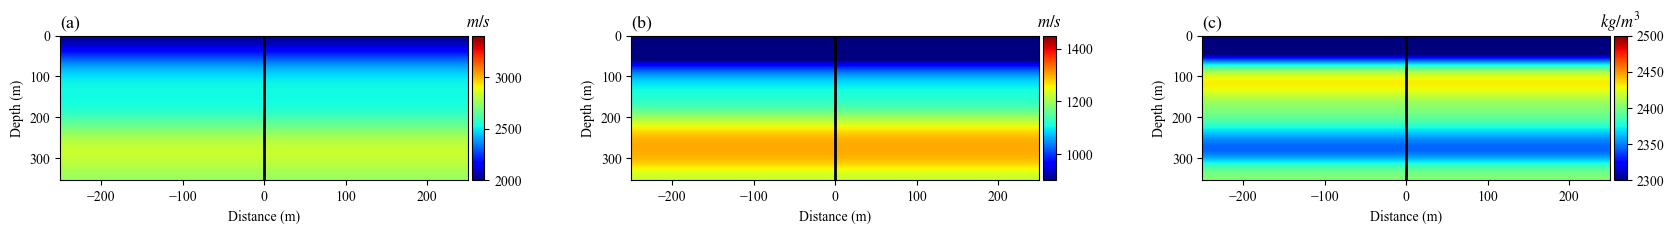

In [8]:

color_bar = 'jet'
font_size = 10
aspect_num = 0.5
std_scale = 3
dx = 5
dz =5
nx = 201


smoothing_parameter = 0
plot_offset = 0
scaled_dim=50
left_location = (nx//2-scaled_dim)
right_location = (nx//2-scaled_dim)

fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(vp_init[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=2000,vmax=3400)
ax.axvline(x=0, linewidth=2, color='k')
ax.set_title("(a)", fontsize=font_size+3, loc='left')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$m/s$')

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(vs_init[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=900, vmax=1450)
ax.axvline(x=0, linewidth=2, color='k')
ax.set_title("(b)", fontsize=font_size+3, loc='left')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$m/s$')



ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(rho_init[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=2300,vmax=2500)
ax.set_title("(c)", fontsize=font_size+3, loc='left')
ax.axvline(x=0, linewidth=2, color='k')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)

cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$kg/m^{3}$')

plt.subplots_adjust(left=0.125,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.1)

In [9]:
# Loading baseline inverted V
vmodel1_list  = torch.load("./line4/results/step2_baseline_vs_bmmisfit/vmodel1_list.pt")
vmodel2_list  = torch.load("./line4/results/step2_baseline_vs_bmmisfit/vmodel2_list.pt")
vmodel3_list  = torch.load("./line4/results/step2_baseline_vs_bmmisfit/vmodel3_list.pt")

from H_V_Smooth import H_Smooth
smooth_value = 4
H_Smooth_fun = H_Smooth(vmodel1_list[-1].squeeze(), smooth_value)
bvp_smooth = H_Smooth_fun()
H_Smooth_fun = H_Smooth(vmodel2_list[-1].squeeze(), smooth_value)
bvs_smooth = H_Smooth_fun()
H_Smooth_fun = H_Smooth(vmodel3_list[-1].squeeze(), smooth_value)
brho_smooth = H_Smooth_fun()

vmin_value_vp = bvp_smooth[5:,:].min()
vmax_value_vp = bvp_smooth[10:,:].max()

vmin_value_vs = bvs_smooth[5:,:].min()
vmax_value_vs = bvs_smooth[5:,:].max()

vmin_value_rho = brho_smooth[:,:].min()
vmax_value_rho = brho_smooth[:,:].max()

In [10]:
# Loading monitor inverted V
vmodel1_list  = torch.load("./line4/results/vmodel1_list.pt")
vmodel2_list  = torch.load("./line4/results/vmodel2_list.pt")
vmodel3_list  = torch.load("./line4/results/vmodel3_list.pt")

H_Smooth_fun = H_Smooth(vmodel1_list[100].squeeze(), smooth_value)
mvp_smooth = H_Smooth_fun()
H_Smooth_fun = H_Smooth(vmodel2_list[-1].squeeze(), smooth_value)
mvs_smooth = H_Smooth_fun()
H_Smooth_fun = H_Smooth(vmodel3_list[60].squeeze(), smooth_value)
mrho_smooth = H_Smooth_fun()

vmin_value_vp = mvp_smooth[5:,:].min()
vmax_value_vp = mvp_smooth[10:,:].max()

vmin_value_vs = mvs_smooth[5:,:].min()
vmax_value_vs = mvs_smooth[5:,:].max()

vmin_value_rho = mrho_smooth[:,:].min()
vmax_value_rho = mrho_smooth[:,:].max()


(71, 201) (71, 201) (71, 201) (71, 201) (71, 201) (71, 201)
(213, 101) (213, 101) (213, 101)
(3, 3, 71, 101)


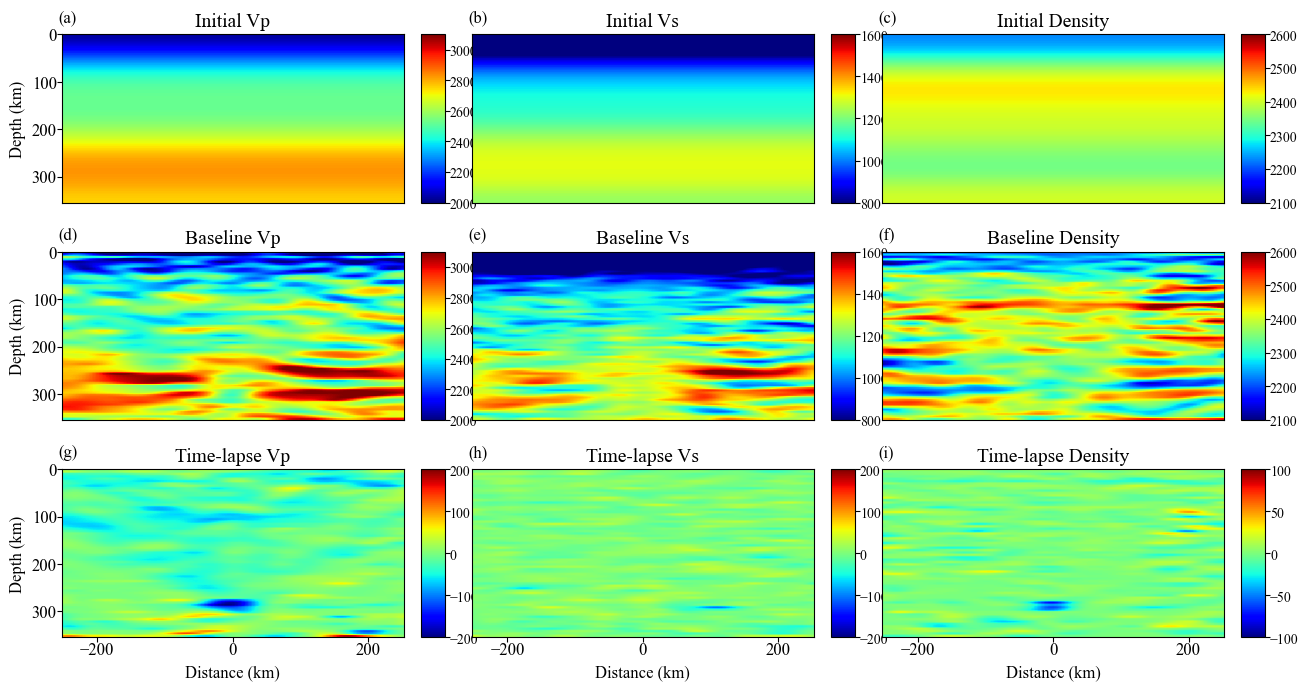

In [11]:
startnum=250//dz
tvp_smooth=mvp_smooth-bvp_smooth
tvs_smooth=mvs_smooth-bvs_smooth
trho_smooth=mrho_smooth-brho_smooth
prediction_model_1 = np.concatenate((vp_init[:,startnum:nx-startnum], vs_init[:,startnum:nx-startnum], rho_init[:,startnum:nx-startnum]), axis=0)
prediction_model_2 = np.concatenate((bvp_smooth[:,startnum:nx-startnum], bvs_smooth[:,startnum:nx-startnum], brho_smooth[:,startnum:nx-startnum]), axis=0)
prediction_model_3 = np.concatenate((tvp_smooth[:,startnum:nx-startnum], tvs_smooth[:,startnum:nx-startnum], trho_smooth[:,startnum:nx-startnum]), axis=0)
print(vp_init.shape, vs_init.shape, rho_init.shape,bvp_smooth.shape, bvs_smooth.shape, brho_smooth.shape)
print(prediction_model_1.shape, prediction_model_2.shape, prediction_model_3.shape)

images_combined = np.vstack((
    prediction_model_1.reshape(1, 3, nz, nx-2*startnum),
    prediction_model_2.reshape(1, 3, nz, nx-2*startnum),
    prediction_model_3.reshape(1, 3, nz, nx-2*startnum),
))
print(images_combined.shape)

fig = plt.figure(figsize=(15, 8))
# Use images_combined in imagesc function
imagesc(fig,
        images_combined,
        vmin=[[2000, 800,2100],[2000,800,2100],[-200,-200,-100]], # Set min for both rows
        vmax=[[3100, 1600,2600],[3100, 1600,2600],[200,200,100]],  # Set max for both rows
        extent=[startnum*dz-nx * dx/2, nx * dx/2-startnum*dz , nz * dz, 0],
        aspect=0.7,
        nRows_nCols=(3, 3),  # Two rows and three columns
        cmap = ['jet', 'jet', 'jet'],
        ylabel="Depth (km)",
        xlabel="Distance (km)",
        xticks=np.arange(-200, (nx * dx)/2-startnum*dz, 200),
        yticks=np.arange(0., (nz * dz), 100),
        fontsize=12,
        cbar_width="7%",
        cbar_height="100%",
        titles=["Initial Vp","Initial Vs","Initial Density","Baseline Vp","Baseline Vs","Baseline Density","Time-lapse Vp","Time-lapse Vs","Time-lapse Density",],
        )

In [12]:
print(tvp_smooth.min(),tvp_smooth.max())
print(trho_smooth.min(),trho_smooth.max())

-200.11719 209.02197
-73.44238 64.05615


In [13]:
vmodel2_list  = torch.load("./line4/results/vmodel2_list.pt")
H_Smooth_fun = H_Smooth(vmodel2_list[-1].squeeze(), smooth_value)
vs1_smooth = H_Smooth_fun()
vmodel2_list  = torch.load("./line4/results/step2_baseline_vs_bmmisfit/vmodel2_list.pt")
H_Smooth_fun = H_Smooth(vmodel2_list[-1].squeeze(), smooth_value)
vs2_smooth = H_Smooth_fun()
vsd=vs2_smooth-vs1_smooth
mvs_smooth=bvs_smooth+vsd
tvs_smooth=vsd.copy()

tlvp=tvp_smooth.copy()
tlrho=trho_smooth.copy()
tlvs=tvs_smooth.copy()

process_mask = np.ones_like(trho_smooth, dtype=bool)
process_mask[55:65, 65:180] = False
mask = (tlvp < 0) & process_mask
tlvp[mask] *= 0.85
mask_pos = (tlvp > 0)
tlvp[mask_pos] *= 1
tvp_smooth=tlvp.copy()
mvp_smooth=bvp_smooth+tvp_smooth

process_mask = np.ones_like(trho_smooth, dtype=bool)
process_mask[55:65, 100:180] = False
mask = (tlrho < 0) & process_mask
tlrho[mask] *= 1
mask_pos = (tlrho > 0)
tlrho[mask_pos] *= 1
trho_smooth=tlrho.copy()
mrho_smooth=brho_smooth+trho_smooth

process_mask = np.ones_like(tvs_smooth, dtype=bool)
mask = (tlvs < 0) & process_mask
tlvs[mask] *= 0.5
mask_pos = (tlvs > 0)
tlvs[mask_pos] *= 0.5
tvs_smooth=tlvs.copy()
mvs_smooth=bvs_smooth+tvs_smooth

(71, 201) (71, 201) (71, 201) (71, 201) (71, 201) (71, 201)
(213, 121) (213, 121) (213, 121)
(3, 3, 71, 121)


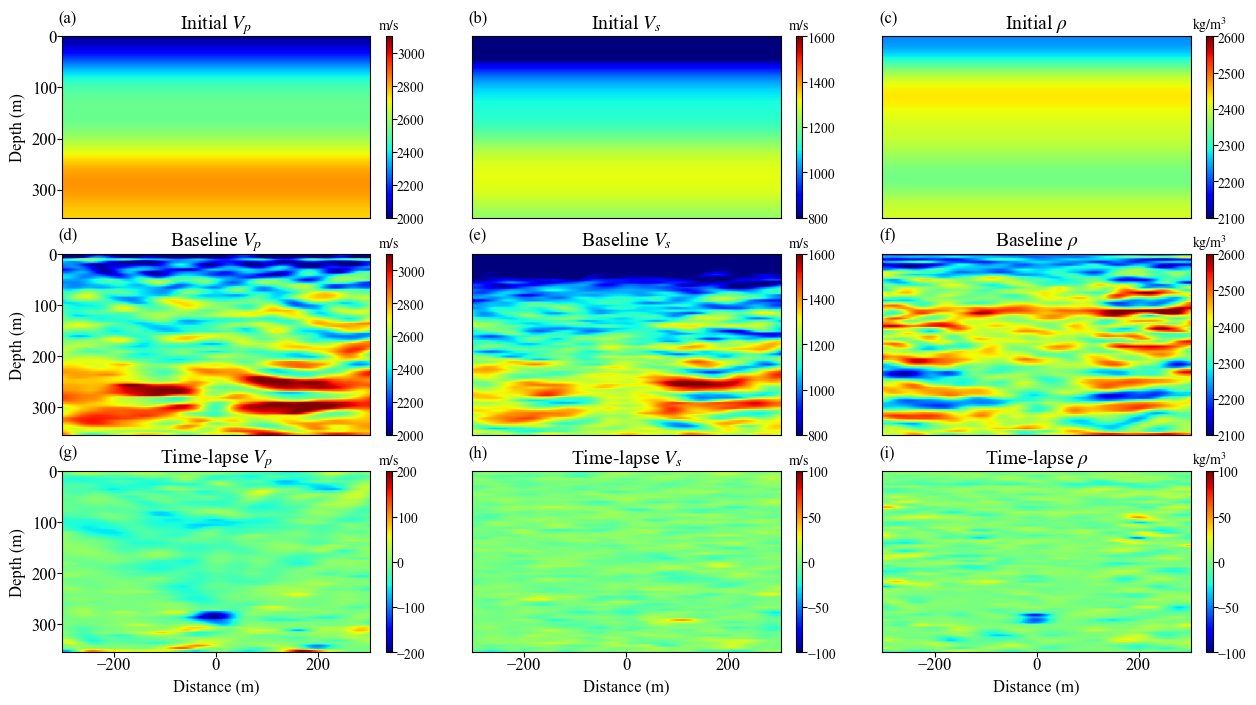

In [14]:
startnum=200//dz
prediction_model_1 = np.concatenate((vp_init[:,startnum:nx-startnum], vs_init[:,startnum:nx-startnum], rho_init[:,startnum:nx-startnum]), axis=0)
prediction_model_2 = np.concatenate((bvp_smooth[:,startnum:nx-startnum], bvs_smooth[:,startnum:nx-startnum], brho_smooth[:,startnum:nx-startnum]), axis=0)
prediction_model_3 = np.concatenate((tvp_smooth[:,startnum:nx-startnum], tvs_smooth[:,startnum:nx-startnum], trho_smooth[:,startnum:nx-startnum]), axis=0)
print(vp_init.shape, vs_init.shape, rho_init.shape,bvp_smooth.shape, bvs_smooth.shape, brho_smooth.shape)
print(prediction_model_1.shape, prediction_model_2.shape, prediction_model_3.shape)

images_combined = np.vstack((
    prediction_model_1.reshape(1, 3, nz, nx-2*startnum),
    prediction_model_2.reshape(1, 3, nz, nx-2*startnum),
    prediction_model_3.reshape(1, 3, nz, nx-2*startnum),
))
print(images_combined.shape)

fig = plt.figure(figsize=(15, 8))
# Use images_combined in imagesc function
imagesc(fig,
        images_combined,
        vmin=[[2000, 800,2100],[2000,800,2100],[-200,-100,-100]], # Set min for both rows
        vmax=[[3100, 1600,2600],[3100, 1600,2600],[200,100,100]],  # Set max for both rows
        extent=[startnum*dz-nx * dx/2, nx * dx/2-startnum*dz , nz * dz, 0],
        aspect=1,
        nRows_nCols=(3, 3),  # Two rows and three columns
        cmap = ['jet', 'jet', 'jet'],
        ylabel="Depth (m)",
        xlabel="Distance (m)",       
        xticks=np.arange(-200, (nx * dx)/2-startnum*dz, 200),
        yticks=np.arange(0., (nz * dz), 100),
        fontsize=12,
        cbar_width="2%",
        cbar_height="100%",
        titles=["Initial $V_p$","Initial $V_s$",r"Initial $\rho$","Baseline $V_p$","Baseline $V_s$",
                r"Baseline $\rho$","Time-lapse $V_p$","Time-lapse $V_s$",r"Time-lapse $\rho$",],
        cbar_titles=[r"$\mathrm{m/s}$",r"$\mathrm{m/s}$",r"$\mathrm{kg/m^{3}}$",r"$\mathrm{m/s}$",
                     r"$\mathrm{m/s}$",r"$\mathrm{kg/m^{3}}$",r"$\mathrm{m/s}$",r"$\mathrm{m/s}$",r"$\mathrm{kg/m^{3}}$"]
        )

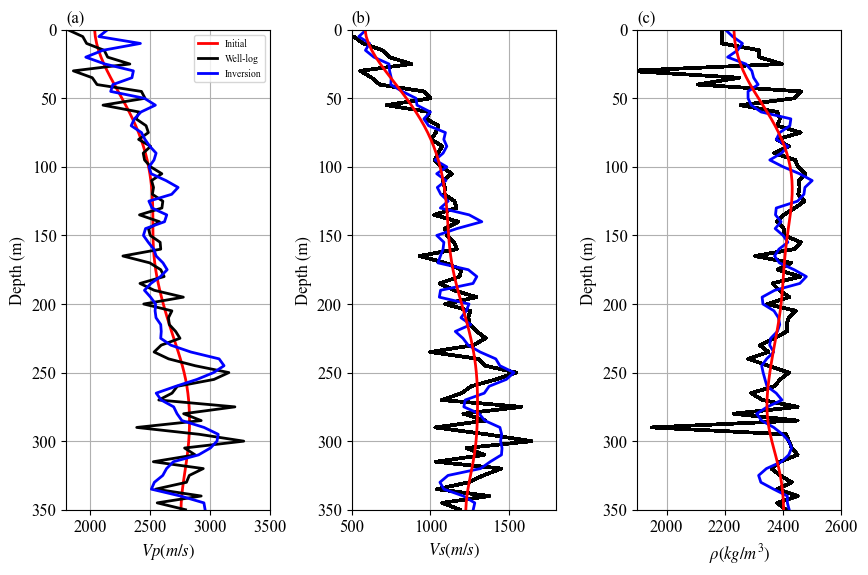

In [15]:
font_size = 12
dz = 5
z = np.arange(0, nz)*dz
profile_index = int(nx//2)+15
line_width = 2
smoothing_factor = 1

fig = plt.figure(figsize=(10, 6))

gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, 0])
ax.plot(((vp_init[:,profile_index])), z, linewidth=line_width,color = 'r', label='Initial')
ax.plot(vp_well_initial_model[:nz,profile_index], z,  linewidth=line_width, color = 'k', label='Well-log')
ax.plot(((bvp_smooth[:,profile_index])), z, linewidth=line_width,color = 'blue', label='Inversion')
ax.set_title('(a)', loc='left', fontsize =font_size)
ax.set_ylabel("Depth (m)", fontsize =font_size)
ax.set_xlabel(r"$Vp (m/s)$", fontsize =font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
ax.legend(loc='best', fontsize=font_size-5)
ax.invert_yaxis()
ax.grid()
ax.set_xlim(1800, 3500)
ax.set_ylim(350, 0)

ax = fig.add_subplot(gs[0, 1])
ax.plot(vs_well_initial_model[:nz], z,  linewidth=line_width, color = 'k', label='Smoothed Vs well-log')
ax.plot(((bvs_smooth[:,profile_index])), z, linewidth=line_width,color = 'blue', label='RNN FWI Vs result')
ax.plot(((vs_init[:,profile_index])), z, linewidth=line_width,color = 'r', label='RNN FWI Vp init')
ax.set_title('(b)', loc='left', fontsize =font_size)
ax.set_ylabel("Depth (m)", fontsize =font_size)
ax.set_xlabel(r"$Vs (m/s)$", fontsize =font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
#ax.legend(loc=1, fontsize =font_size )
ax.invert_yaxis()
ax.grid()
ax.set_xlim(500, 1800)
ax.set_ylim(350, 0)

profile_index = int(nx//2)+10

ax = fig.add_subplot(gs[0, 2])
ax.plot(rho_well_initial_model[:nz], z,  linewidth=line_width, color = 'k', label='Smoothed rho well-log')
ax.plot(((brho_smooth[:,profile_index])), z, linewidth=line_width,color = 'blue', label='RNN FWI rho result')
ax.plot(((rho_init[:,profile_index])), z, linewidth=line_width,color = 'r', label='RNN FWI rho init')
ax.set_title('(c)', loc='left', fontsize =font_size)
ax.set_ylabel("Depth (m)", fontsize =font_size)
ax.set_xlabel(r"$\rho (kg/m^{3})$", fontsize =font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
#ax.legend(loc=1, fontsize =font_size )
ax.invert_yaxis()
ax.grid()
ax.set_xlim(1900, 2600)
ax.set_ylim(350, 0)


plt.subplots_adjust(left=0.125,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)


In [ ]:
from scipy.io import savemat

savemat("snowflake_2026.mat", {"Basevp": bvp_smooth, "Basevs": bvs_smooth, "Baserho": brho_smooth, "Monvp": mvp_smooth, "Monvs": mvs_smooth, "Monrho": mrho_smooth})